<a href="https://colab.research.google.com/github/bhumichauhan9911-cpu/bhumi-chauhan/blob/main/ml_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
import joblib

In [ ]:
data="/content/Exam_Score_Prediction.csv"

In [ ]:
df=pd.read_csv(data)
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33695,33697,20,female,bcom,2.90,47.5,yes,6.5,average,online,low,moderate,18.0
33696,33698,20,female,bca,1.20,42.1,yes,5.4,poor,group-study,medium,hard,22.0
33697,33699,21,female,bcom,2.00,53.7,yes,4.5,average,self-study,medium,moderate,39.0
33698,33700,20,male,bba,2.10,38.4,yes,5.9,poor,online,medium,hard,12.0


In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [ ]:
df.tail()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
33695,33697,20,female,bcom,2.9,47.5,yes,6.5,average,online,low,moderate,18.0
33696,33698,20,female,bca,1.2,42.1,yes,5.4,poor,group-study,medium,hard,22.0
33697,33699,21,female,bcom,2.0,53.7,yes,4.5,average,self-study,medium,moderate,39.0
33698,33700,20,male,bba,2.1,38.4,yes,5.9,poor,online,medium,hard,12.0
33699,33701,19,female,bcom,1.2,58.6,no,6.3,poor,group-study,medium,hard,33.0


In [ ]:
df.sample(5)

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
12928,12929,17,female,bca,0.60,44.6,yes,6.1,average,online videos,high,moderate,38.7
286,287,18,other,b.sc,0.95,49.2,yes,8.4,average,group study,medium,hard,43.2
31446,31448,20,female,bca,1.60,52.0,no,5.2,poor,self-study,low,hard,3.0
12593,12594,23,male,diploma,3.20,75.9,yes,9.5,good,online videos,high,moderate,84.1
12042,12043,21,other,b.sc,3.94,66.6,yes,6.9,good,mixed,low,moderate,65.4


In [ ]:
df.shape

(33700, 13)

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33700 entries, 0 to 33699
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        33700 non-null  int64  
 1   age               33700 non-null  int64  
 2   gender            33700 non-null  object 
 3   course            33700 non-null  object 
 4   study_hours       33700 non-null  float64
 5   class_attendance  33700 non-null  float64
 6   internet_access   33700 non-null  object 
 7   sleep_hours       33700 non-null  float64
 8   sleep_quality     33700 non-null  object 
 9   study_method      33700 non-null  object 
 10  facility_rating   33700 non-null  object 
 11  exam_difficulty   33700 non-null  object 
 12  exam_score        33700 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 3.3+ MB


In [ ]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,33700.000000,33700.000000,33700.000000,33700.000000,33700.000000,33700.000000
mean,16850.909258,20.268309,3.291355,60.835552,6.455395,45.009095
std,9728.915133,1.993580,2.030057,17.927317,1.551206,26.715067
min,1.000000,17.000000,0.080000,35.000000,4.100000,0.000000
25%,8425.750000,19.000000,1.730000,46.400000,5.200000,23.000000
50%,16850.500000,20.000000,2.800000,56.000000,6.100000,42.400000
75%,25276.250000,22.000000,4.650000,74.800000,7.500000,66.800000
max,33701.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [ ]:
df.describe(include="object")

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,33700,33700,33700,33700,33700,33700,33700
unique,3,9,2,3,7,3,3
top,male,bca,yes,average,self-study,medium,moderate
freq,13527,6289,23769,13668,8631,13614,16708


In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.shape

(33700, 13)

In [ ]:
df["Result"]=df["exam_score"].apply(
    lambda x:1 if x>=40 else 0
)

In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,Result
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,1
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,1
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,1
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,0
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,1


In [ ]:
df["Result"].value_counts()

,count
Result,
1,17425
0,16275


In [ ]:
print(df["Result"].value_counts(normalize=True)*100)

Result
1    51.706231
0    48.293769
Name: proportion, dtype: float64


In [ ]:
df=df.drop("student_id",axis=1)

In [ ]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,Result
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,1
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,1
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,1
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,0
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,1


In [ ]:
df.dtypes

,0
age,int64
gender,object
course,object
study_hours,float64
class_attendance,float64
internet_access,object
sleep_hours,float64
sleep_quality,object
study_method,object
facility_rating,object


In [ ]:
categorical_columns=df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [ ]:
numerical_columns=df.select_dtypes(
    exclude="object"
).columns

numerical_columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'Result'],
      dtype='object')

In [ ]:
for i in categorical_columns:
    print(i)
    print(df[i].unique())

gender
['male' 'other' 'female']
course
['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com' 'bsc' 'bcom']
internet_access
['yes' 'no']
sleep_quality
['poor' 'average' 'good']
study_method
['coaching' 'online videos' 'mixed' 'self-study' 'group study'
 'group-study' 'online']
facility_rating
['low' 'medium' 'high']
exam_difficulty
['hard' 'moderate' 'easy']


In [ ]:

le=LabelEncoder()

for col in categorical_columns:
    df[col]=le.fit_transform(df[col])

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33700 entries, 0 to 33699
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               33700 non-null  int64  
 1   gender            33700 non-null  int64  
 2   course            33700 non-null  int64  
 3   study_hours       33700 non-null  float64
 4   class_attendance  33700 non-null  float64
 5   internet_access   33700 non-null  int64  
 6   sleep_hours       33700 non-null  float64
 7   sleep_quality     33700 non-null  int64  
 8   study_method      33700 non-null  int64  
 9   facility_rating   33700 non-null  int64  
 10  exam_difficulty   33700 non-null  int64  
 11  exam_score        33700 non-null  float64
 12  Result            33700 non-null  int64  
dtypes: float64(4), int64(9)
memory usage: 3.3 MB


In [ ]:
plt.style.use("ggplot")
sns.set(font_scale=1.1)

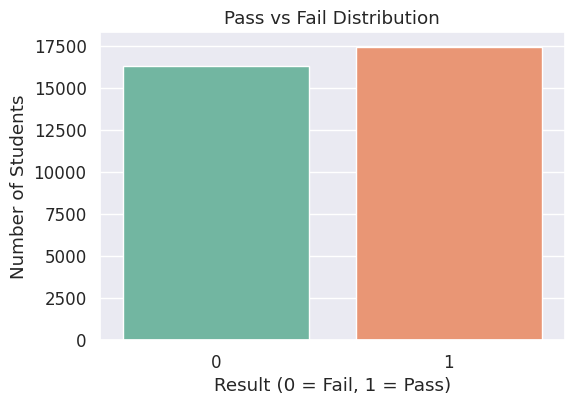

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Result",
    data=df,
    palette="Set2"
)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Result (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
print(df["Result"].value_counts())

Result
1    17425
0    16275
Name: count, dtype: int64


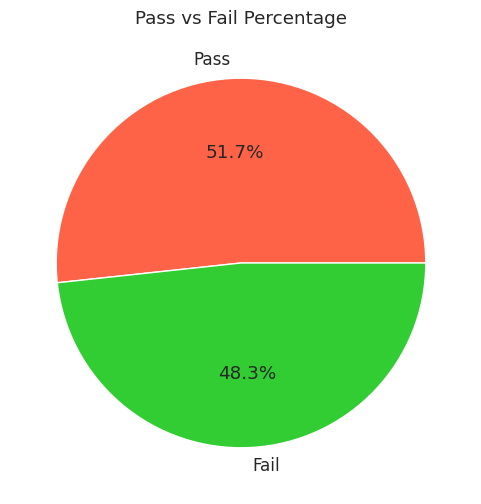

In [ ]:
plt.figure(figsize=(6,6))

df["Result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["tomato","limegreen"],
    labels=["Pass","Fail"]
)

plt.ylabel("")
plt.title("Pass vs Fail Percentage")

plt.show()

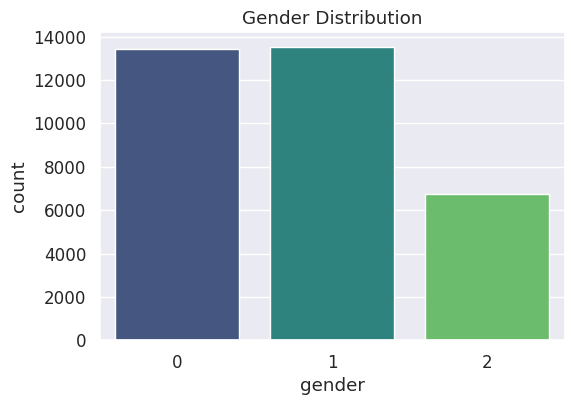

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="gender",
    data=df,
    palette="viridis"
)

plt.title("Gender Distribution")

plt.show()

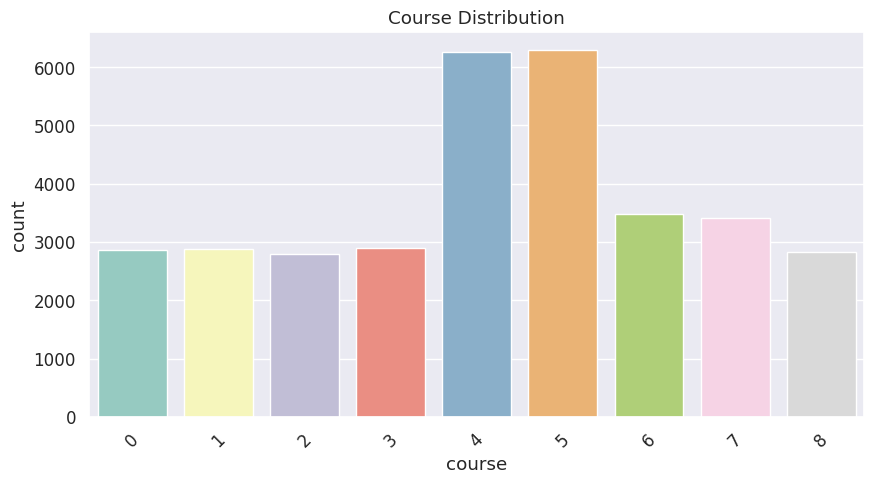

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="course",
    data=df,
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("Course Distribution")

plt.show()

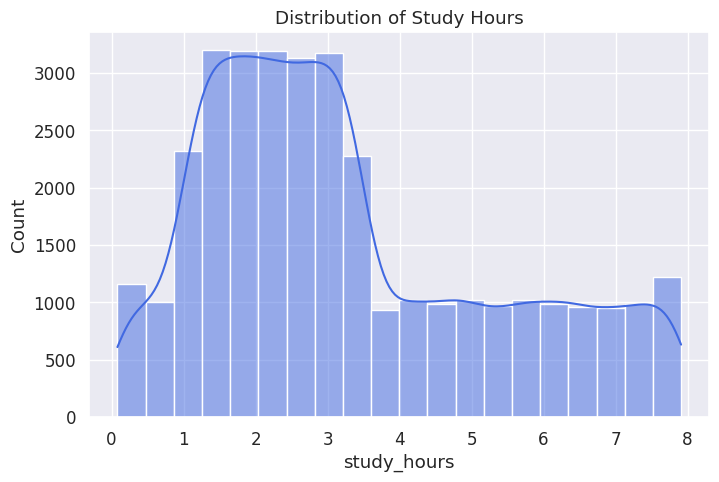

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["study_hours"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Study Hours")

plt.show()

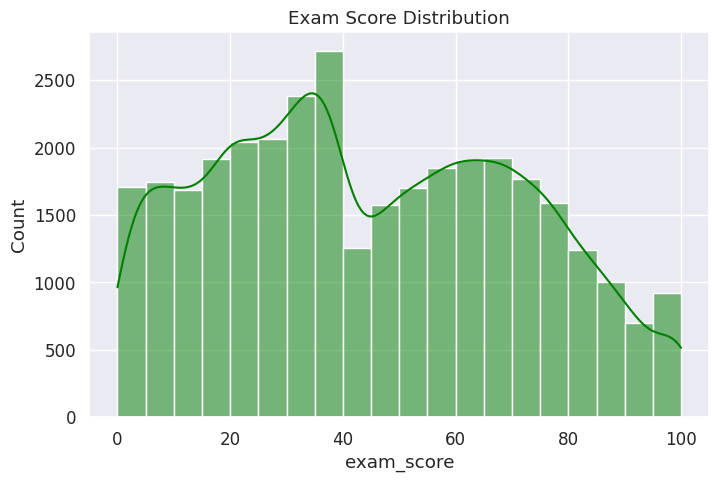

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["exam_score"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Exam Score Distribution")

plt.show()

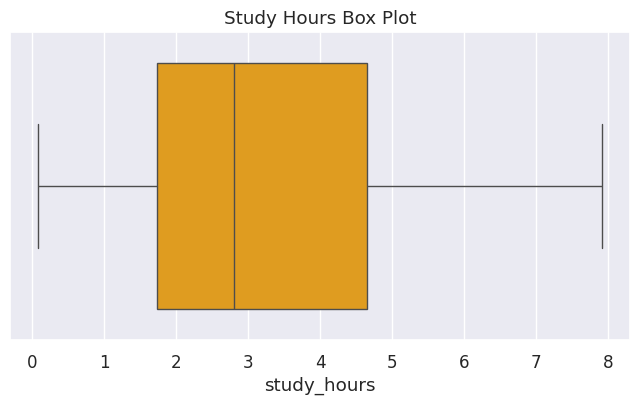

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["study_hours"],
    color="orange"
)

plt.title("Study Hours Box Plot")

plt.show()

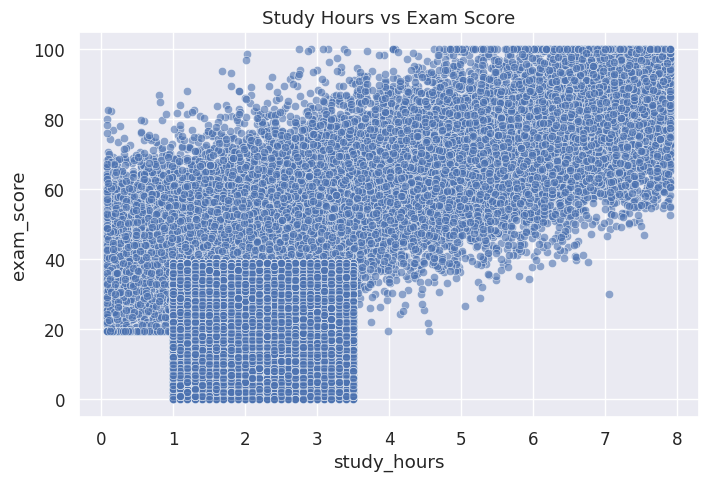

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="study_hours",
    y="exam_score",
    data=df,
    alpha=0.6
)

plt.title("Study Hours vs Exam Score")

plt.show()

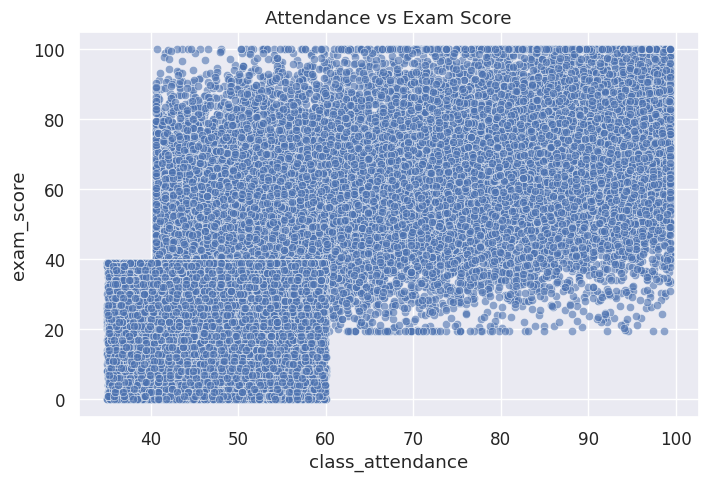

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="class_attendance",
    y="exam_score",
    data=df,
    alpha=0.6
)

plt.title("Attendance vs Exam Score")

plt.show()

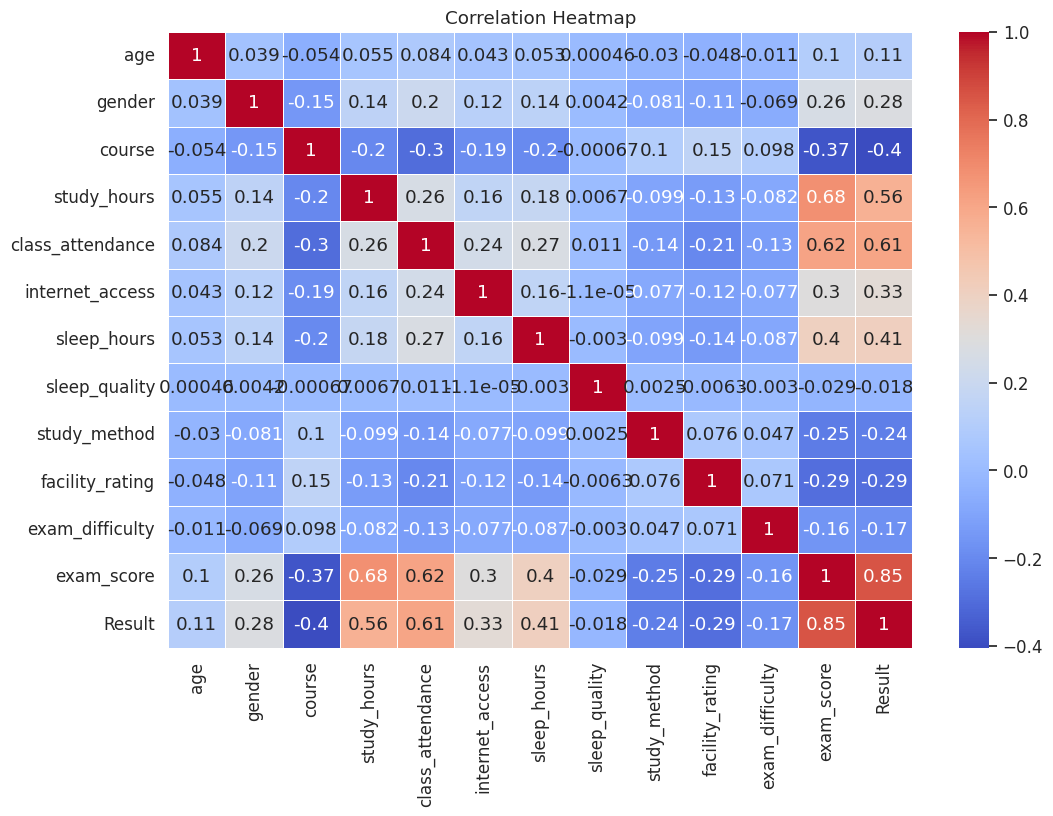

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

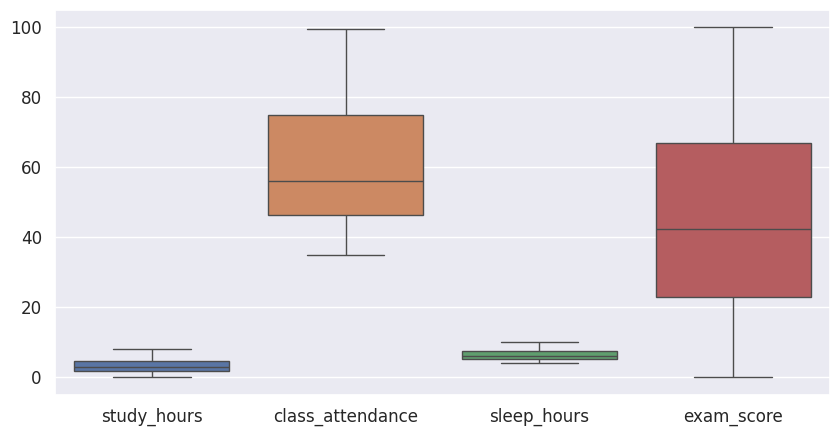

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[
        [
            "study_hours",
            "class_attendance",
            "sleep_hours",
            "exam_score"
        ]
    ]
)

plt.show()

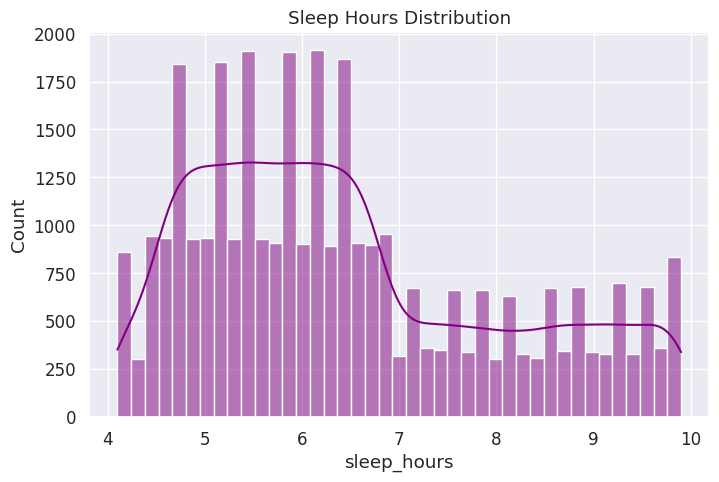

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["sleep_hours"],
    kde=True,
    color="purple"
)

plt.title("Sleep Hours Distribution")

plt.show()

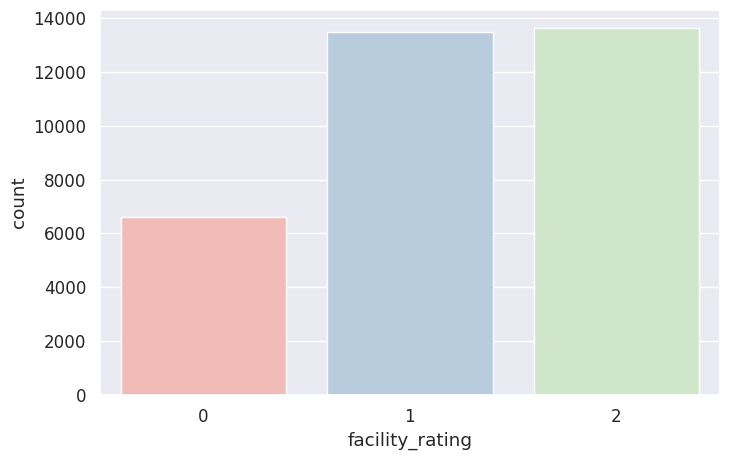

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="facility_rating",
    data=df,
    palette="Pastel1"
)

plt.show()

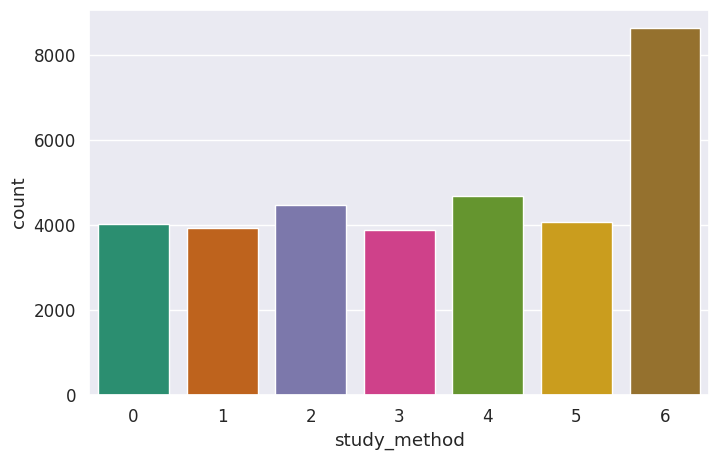

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="study_method",
    data=df,
    palette="Dark2"
)

plt.show()

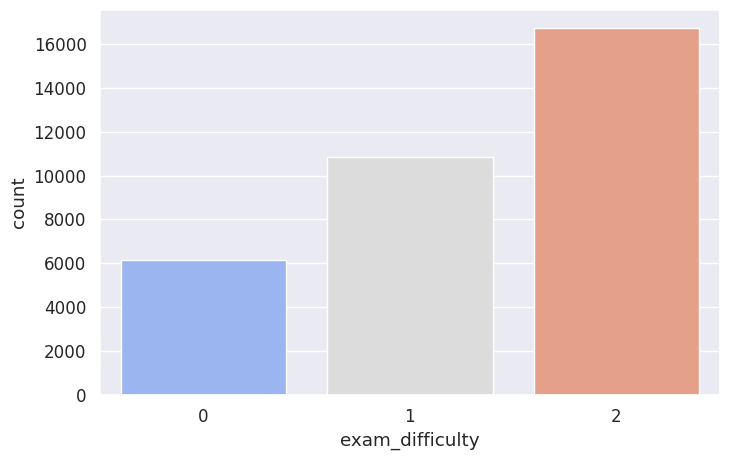

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="exam_difficulty",
    data=df,
    palette="coolwarm"
)

plt.show()

In [ ]:
# Features (Independent Variables)
X = df.drop(["exam_score", "Result"], axis=1)

# Target Variable
y = df["Result"]

In [ ]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (33700, 11)
Target Shape : (33700,)


In [ ]:
X.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,17,1,8,2.78,92.9,1,7.4,2,0,1,1
1,23,2,5,3.37,64.8,1,4.6,0,5,2,2
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2
3,20,2,8,0.67,48.4,1,5.8,0,5,1,2
4,20,0,8,0.89,71.6,1,9.8,2,0,1,2


In [ ]:
y.head()

,Result
0,1
1,1
2,1
3,0
4,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_prediction = dt_model.predict(X_test)

In [ ]:
dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.9130563798219584


In [ ]:
cm = confusion_matrix(y_test, dt_prediction)

cm

array([[2969,  286],
       [ 300, 3185]])

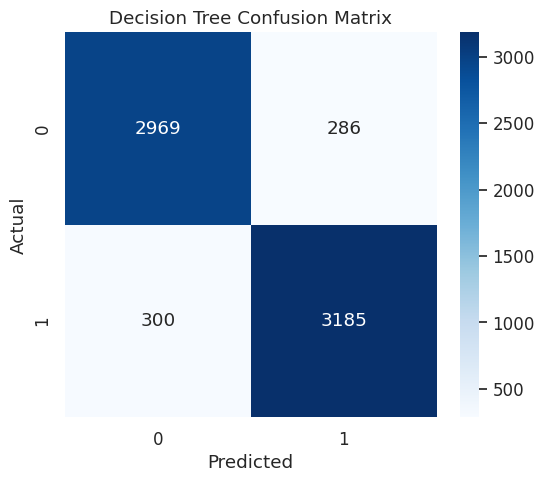

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, dt_prediction))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3255
           1       0.92      0.91      0.92      3485

    accuracy                           0.91      6740
   macro avg       0.91      0.91      0.91      6740
weighted avg       0.91      0.91      0.91      6740



In [ ]:
precision = precision_score(y_test, dt_prediction)

recall = recall_score(y_test, dt_prediction)

f1 = f1_score(y_test, dt_prediction)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Precision : 0.9176029962546817
Recall : 0.9139167862266858
F1 Score : 0.9157561817136285


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_prediction = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9402077151335312


In [ ]:
cm_rf = confusion_matrix(y_test, rf_prediction)

cm_rf

array([[2960,  295],
       [ 108, 3377]])

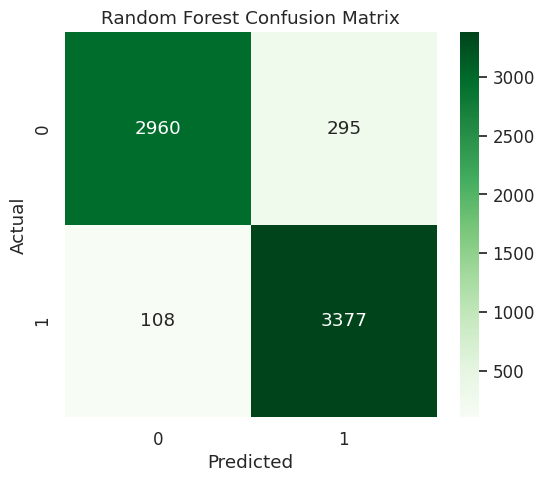

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3255
           1       0.92      0.97      0.94      3485

    accuracy                           0.94      6740
   macro avg       0.94      0.94      0.94      6740
weighted avg       0.94      0.94      0.94      6740



In [ ]:
rf_precision = precision_score(y_test, rf_prediction)

rf_recall = recall_score(y_test, rf_prediction)

rf_f1 = f1_score(y_test, rf_prediction)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

Precision : 0.9196623093681917
Recall : 0.9690100430416069
F1 Score : 0.9436914908481208


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores")

print(cv_scores)

print("Average Accuracy :", cv_scores.mean())

Cross Validation Scores
[0.62062315 0.97878338 0.97848665 0.97774481 0.98026706]
Average Accuracy : 0.9071810089020771


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy
    ]

})

comparison

,Model,Accuracy
0,Decision Tree,0.913056
1,Random Forest,0.940208


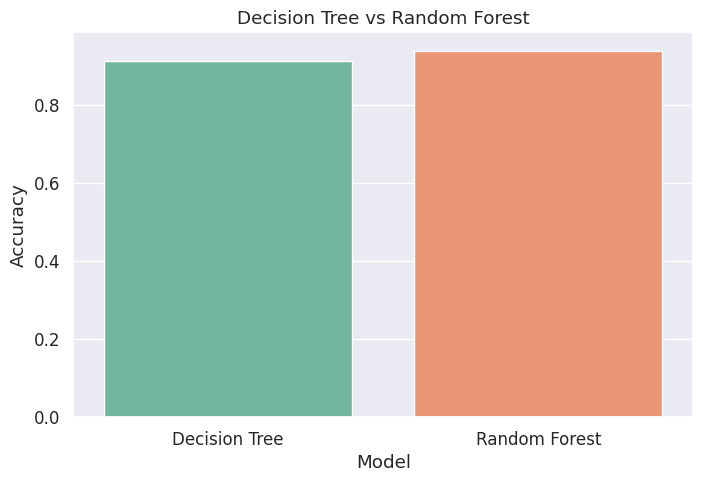

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="Set2"
)

plt.title("Decision Tree vs Random Forest")

plt.show()

In [ ]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Random Forest,0.940208
0,Decision Tree,0.913056


In [ ]:
lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
lr_prediction = lr_model.predict(X_test)

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9253709198813056


In [ ]:
print(classification_report(y_test, lr_prediction))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      3255
           1       0.94      0.92      0.93      3485

    accuracy                           0.93      6740
   macro avg       0.93      0.93      0.93      6740
weighted avg       0.93      0.93      0.93      6740



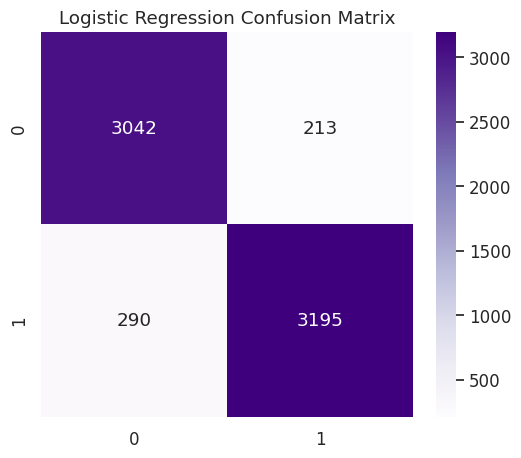

In [ ]:
lr_cm = confusion_matrix(y_test, lr_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
knn_prediction = knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, knn_prediction)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 0.9228486646884273


In [ ]:
print(classification_report(y_test, knn_prediction))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      3255
           1       0.92      0.93      0.93      3485

    accuracy                           0.92      6740
   macro avg       0.92      0.92      0.92      6740
weighted avg       0.92      0.92      0.92      6740



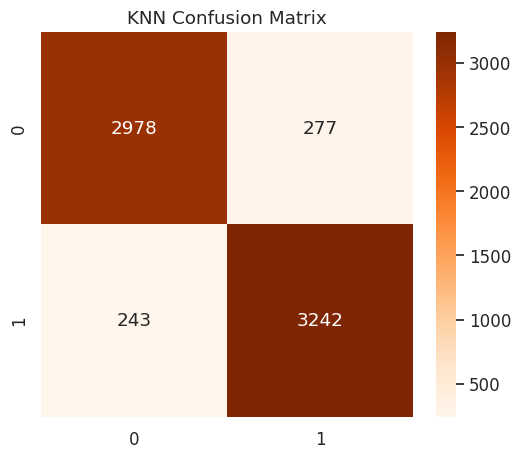

In [ ]:
knn_cm = confusion_matrix(y_test, knn_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("KNN Confusion Matrix")

plt.show()

In [ ]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [ ]:
svm_prediction = svm_model.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_prediction)

print("SVM Accuracy :", svm_accuracy)

SVM Accuracy : 0.9412462908011869


In [ ]:
print(classification_report(y_test, svm_prediction))

              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3255
           1       0.92      0.97      0.94      3485

    accuracy                           0.94      6740
   macro avg       0.94      0.94      0.94      6740
weighted avg       0.94      0.94      0.94      6740



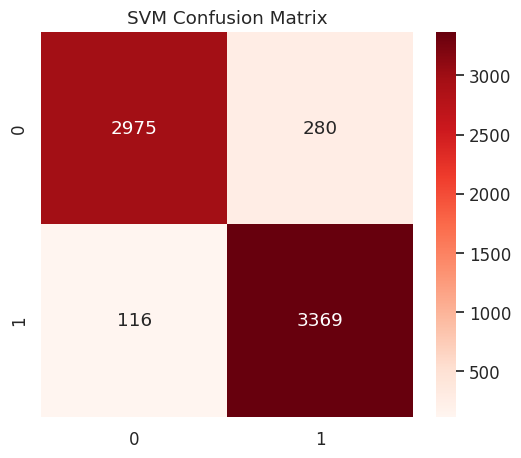

In [ ]:
svm_cm = confusion_matrix(y_test, svm_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        lr_accuracy,
        knn_accuracy,
        svm_accuracy
    ]

})

comparison

,Model,Accuracy
0,Decision Tree,0.913056
1,Random Forest,0.940208
2,Logistic Regression,0.925371
3,KNN,0.922849
4,SVM,0.941246


In [ ]:
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
4,SVM,0.941246
1,Random Forest,0.940208
2,Logistic Regression,0.925371
3,KNN,0.922849
0,Decision Tree,0.913056


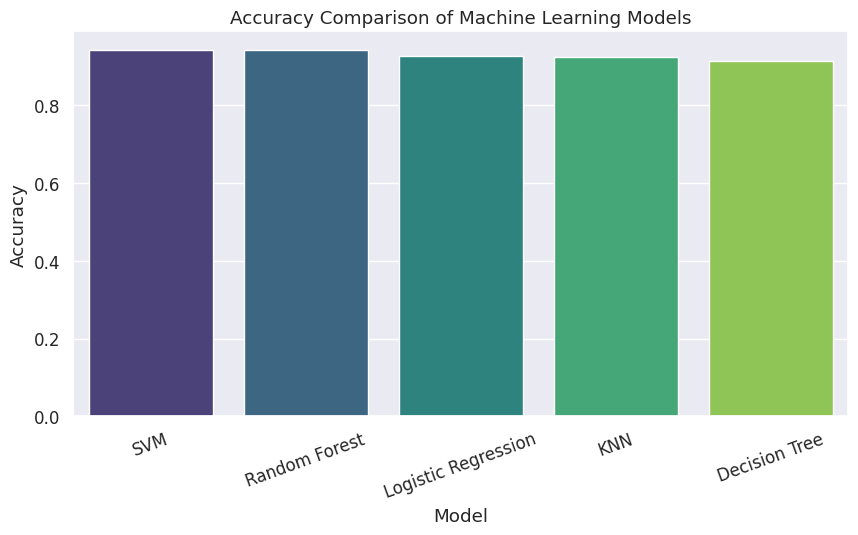

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.show()

In [ ]:
best_model = comparison.iloc[0]

print(best_model)

Model            SVM
Accuracy    0.941246
Name: 4, dtype: object


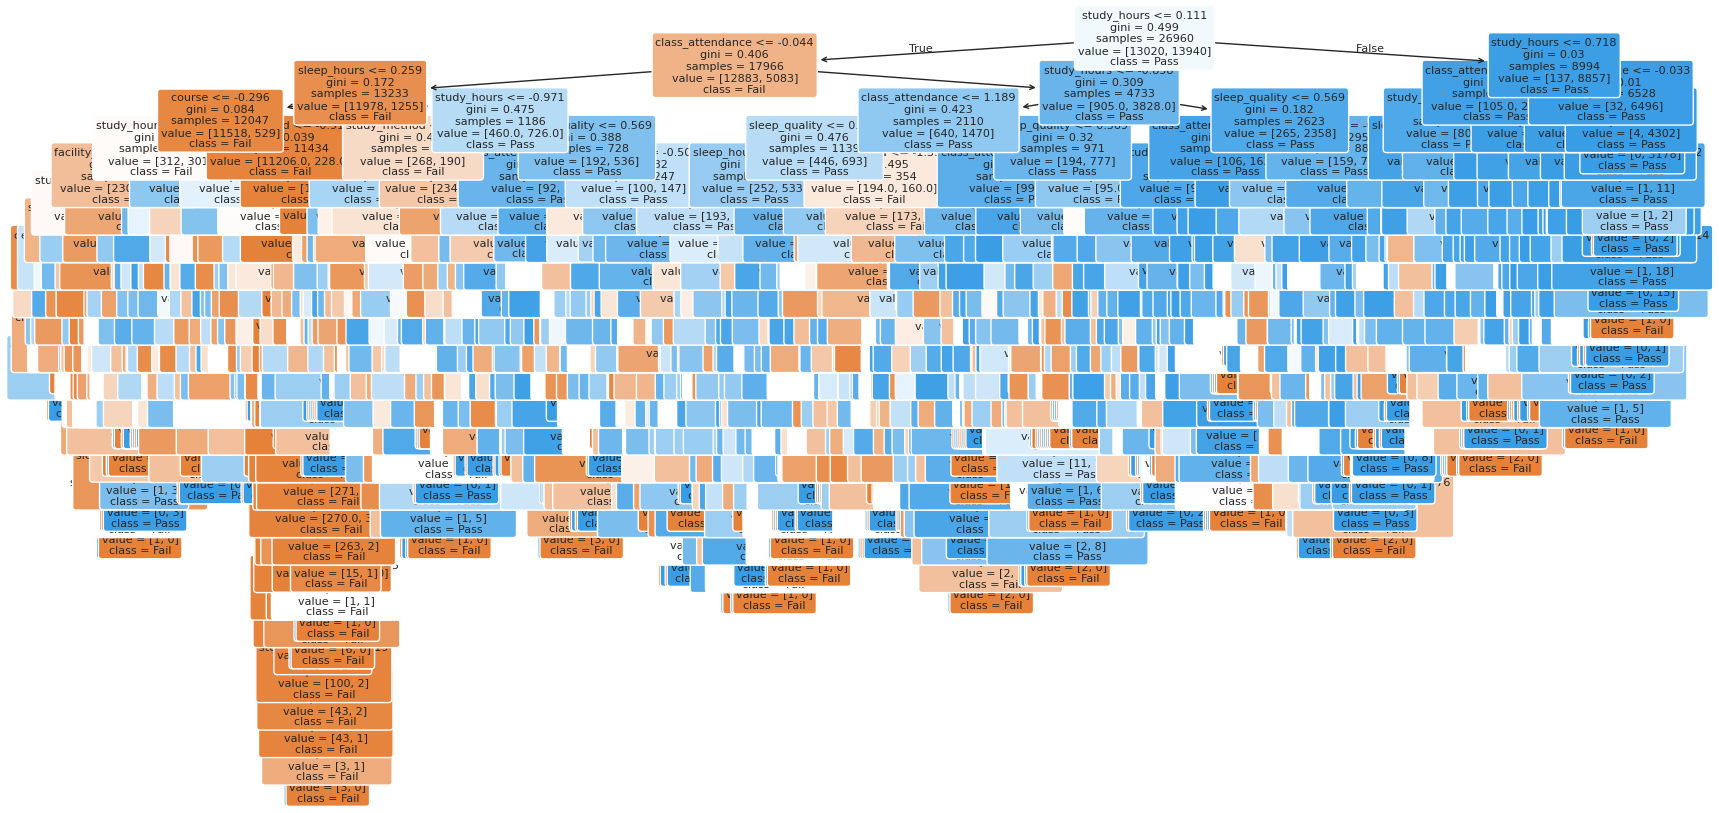

In [ ]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
new_student = pd.DataFrame({

    "age":[20],
    "gender":[1],
    "course":[2],
    "study_hours":[6],
    "class_attendance":[90],
    "internet_access":[1],
    "sleep_hours":[7],
    "sleep_quality":[2],
    "study_method":[1],
    "facility_rating":[4],
    "exam_difficulty":[2]

})

In [ ]:
new_student = scaler.transform(new_student)

prediction = rf_model.predict(new_student)

if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

Prediction : PASS


In [ ]:
joblib.dump(rf_model, "student_result_prediction.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
loaded_model = joblib.load(
    "student_result_prediction.pkl"
)

loaded_model

RandomForestClassifier(random_state=42)

In [ ]:
loaded_model.predict(new_student)

array([1])

In [ ]:
summary = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy,
        lr_accuracy,
        knn_accuracy,
        svm_accuracy
    ]

})

summary.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
4,SVM,0.941246
1,Random Forest,0.940208
2,Logistic Regression,0.925371
3,KNN,0.922849
0,Decision Tree,0.913056


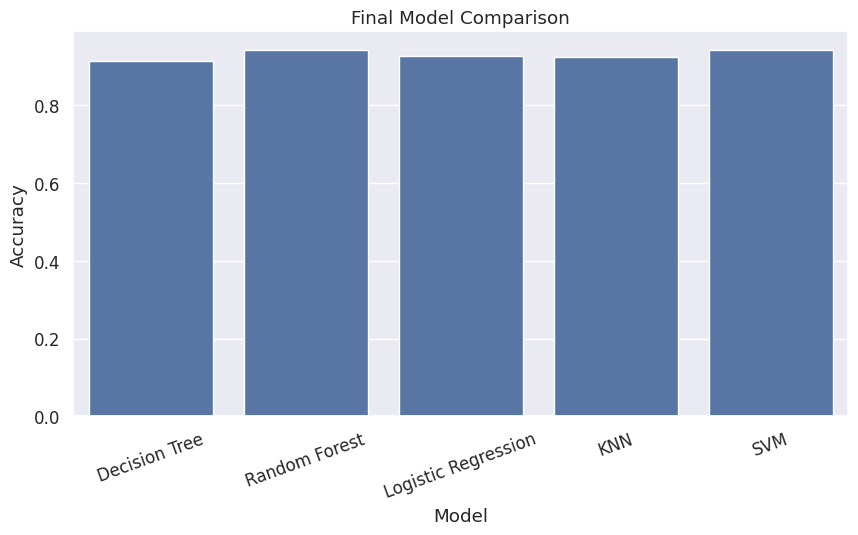

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=summary,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)

plt.title("Final Model Comparison")

plt.show()

In [ ]:
df.memory_usage()

,0
Index,132
age,269600
gender,269600
course,269600
study_hours,269600
class_attendance,269600
internet_access,269600
sleep_hours,269600
sleep_quality,269600
study_method,269600
